In [2]:
# flake8: noqa: T201

import os
from functools import partial

import matplotlib.pyplot as plt
import torch
from mattergen.common.data.datamodule import CrystDataModule
from omegaconf import OmegaConf

from src.kldm.data.dataset import MP20
from src.kldm.data.dataset_transform import filter_elements, filter_energy_above_hull
from src.kldm.data.transform import ConcatFeatures, ContinuousIntervalLattice, FullyConnectedGraph
from src.kldm.utils.plot import mp_20_plot

os.chdir("/workspace")

In [3]:
MP20_dataset = MP20(root="data", split="train", download=True)

MP20_dataset

Dataset MP20
    Number of samples: 27136
    Root location: data
    Split: train

## Dataset: MP20

In [4]:
df = MP20_dataset.df
df.head()

,Unnamed: 0.1,Unnamed: 0,material_id,formation_energy_per_atom,dft_band_gap,pretty_formula,energy_above_hull,elements,cif,space_group,spacegroup.number.conv,cif.conv
0,0,37228,mp-1221227,-1.637460,0.2133,Na3MnCoNiO6,0.043001,"['Co', 'Mn', 'Na', 'Ni', 'O']",# generated using pymatgen\ndata_Na3MnCoNiO6\n...,C1m1,8,# generated using pymatgen\ndata_Na3MnCoNiO6\n...
1,1,19480,mp-974729,-0.314759,0.0000,Nd(Al2Cu)4,0.000000,"['Al', 'Cu', 'Nd']",# generated using pymatgen\ndata_Nd(Al2Cu)4\n_...,I4/mmm,139,# generated using pymatgen\ndata_Nd(Al2Cu)4\n_...
2,2,29624,mp-1185360,-0.193761,0.0000,LiMnIr2,0.018075,"['Ir', 'Li', 'Mn']",# generated using pymatgen\ndata_LiMnIr2\n_sym...,Fm-3m,225,# generated using pymatgen\ndata_LiMnIr2\n_sym...
3,3,38633,mp-1188861,-0.584694,3.8556,LiCSN,0.048847,"['C', 'Li', 'N', 'S']",# generated using pymatgen\ndata_LiCSN\n_symme...,Pnma,62,# generated using pymatgen\ndata_LiCSN\n_symme...
4,4,10889,mp-677272,-2.474759,0.4707,La2EuS4,0.000000,"['Eu', 'La', 'S']",# generated using pymatgen\ndata_La2EuS4\n_sym...,I-42d,122,# generated using pymatgen\ndata_La2EuS4\n_sym...


When processed, each data point $\bm{x}$ in the dataset is a `ChemGraph` object with the following structure:
- **Fractional coordinates:** (`pos`) are fractional coordinates $\bm{f} \in [0,1)^{3 \times K}$, where each row $i$ is $\bm{f}_i = [x_i, y_i, z_i]$.
- **Lattice:** (`cell`) are lattice vectors $\bm{l} \in \mathbb{R}^{3 \times 3}$.
- **Atom types:** (`atomic_numbers`) are atom types $\bm{a} \in \mathbb{Z}^K$.
- **Number of atoms:** (`num_atoms`) are simply the number of atoms (not unique) $K \in \mathbb{Z}$.
- **Number of nodes:** (`num_nodes`) are number of nodes in the graph.

So we have the structure (excluding superfluous metadata) as:
$$
\bm{x} = (\bm{f}, \bm{l}, \bm{a}) \in [0,1)^{3 \times K} \times \mathbb{R}^{3 \times 3} \times \mathbb{Z}^K
$$

A `ChemGraph` data point is equivalent to `torch_geometric.data.Data` and represents one graph/crystal.

### Example: First data point as ChemGraph

In [5]:
# Extract a single data point
x = MP20_dataset[0]

display(x)

ChemGraph(pos=[12, 3], num_atoms=12, num_nodes=12, energy_above_hull=0.04300111159682274, formation_energy_per_atom=-1.6374601125717163, space_group=8, dft_band_gap=0.21330000460147858, atomic_numbers=[12], cell=[1, 3, 3])

In [6]:
print(x)

ChemGraph(pos=[12, 3], num_atoms=12, num_nodes=12, energy_above_hull=0.04300111159682274, formation_energy_per_atom=-1.6374601125717163, space_group=8, dft_band_gap=0.21330000460147858, atomic_numbers=[12], cell=[1, 3, 3])


In [7]:
MP20_dataset[400]

ChemGraph(pos=[14, 3], num_atoms=14, num_nodes=14, energy_above_hull=0.0, formation_energy_per_atom=-0.9246870279312134, space_group=148, dft_band_gap=0.0, atomic_numbers=[14], cell=[1, 3, 3])

In [8]:
print(x.cell.shape, x.num_atoms, x.pos.shape)

torch.Size([1, 3, 3]) tensor(12) torch.Size([12, 3])


#### Graph content

In [9]:
for i in x.items():
    print(i)

('pos', tensor([[6.6651e-01, 1.7850e-03, 3.3302e-01],
        [1.2300e-04, 9.9972e-01, 2.4600e-04],
        [3.3202e-01, 9.9566e-01, 6.6405e-01],
        [4.9982e-01, 5.0073e-01, 9.9965e-01],
        [1.7374e-01, 4.9349e-01, 3.4747e-01],
        [8.3296e-01, 5.0580e-01, 6.6593e-01],
        [7.2317e-02, 6.9008e-01, 1.4463e-01],
        [4.1868e-01, 6.9828e-01, 8.3736e-01],
        [7.4120e-01, 7.1082e-01, 4.8239e-01],
        [9.2925e-01, 3.0547e-01, 8.5849e-01],
        [2.4877e-01, 2.9142e-01, 4.9754e-01],
        [5.8461e-01, 3.0673e-01, 1.6922e-01]]))
('num_atoms', tensor(12))
('num_nodes', tensor(12))
('energy_above_hull', tensor(0.0430))
('formation_energy_per_atom', tensor(-1.6375))
('space_group', tensor(8))
('dft_band_gap', tensor(0.2133))
('atomic_numbers', tensor([11, 11, 11, 25, 27, 28,  8,  8,  8,  8,  8,  8]))
('cell', tensor([[[ 0.6031, -2.9686, -0.0000],
         [-0.0000, -0.0000,  5.6371],
         [-7.6079, -0.0000, -2.4004]]]))


- **Fractional coordinates:** $\bm{f} \in [0,1)^{3 \times 12}$
  - first atom: $\bm{f}_1 = [0.6665, 0.0018, 0.3330] \in [0,1)^3$
- **Lattice:** $$\bm{l} = \begin{bmatrix} 0.6031 & -2.9686 & 0 \\ 0 & 0 & 5.6371 \\ -7.6079 & 0 & -2.4004 \end{bmatrix}$$
- **Atom types:** $\bm{a} = [11, 11, 11, 25, 27, 28,  8,  8,  8,  8,  8,  8] \in \mathbb{Z}^{12}$

#### Periodicity

Taking the first atom position and applying a transformation:
$$
\bm{f}_1' = \bm{f}_1 + [1, 0, 0] = [1.6665, 0.0018, 0.3330]
$$
and apply modulo (torus structure):
$$
\bm{f}_1' \bmod 1 = [0.6665, 0.0018, 0.3330]
$$

We can therefore interpret any such transformation as the same physical atom:
$$
\bm{f} \sim \bm{f} + \bm{k}, \qquad \bm{k} \in \mathbb{Z}^3
$$
so $\bm{f}_1 \in \mathbb{T}^3$.

#### Convert atom to real space

Cartesian position of atom:
$$
\bm{r} = \bm{l} \cdot \bm{f} = \bm{l}_1 \bm{f}^{(x)} + \bm{l}_2 \bm{f}^{(y)} + \bm{l}_3 \bm{f}^{(z)}
$$

Below is an example for the first atom.

In [10]:
f_1 = x.pos[0]  # fractional coordinates for first atom
l_ = x.cell[0]  # lattice parameters
display(l_)

r_1 = f_1 @ l_  # Cartesian coordinates for first atom
r_1

tensor([[ 0.6031, -2.9686, -0.0000],
        [-0.0000, -0.0000,  5.6371],
        [-7.6079, -0.0000, -2.4004]])

tensor([-2.1316, -1.9786, -0.7893])

#### Infinite crystal structure

Defined as:
$$
\bm{f}' = \bm{f} + \bm{k} \bm{1}^T_K
$$

if we pick e.g. $\bm{k} = [1, 0, 0]$, we can get the new atom position as:
$$
\bm{r}_1' = \bm{l}(\bm{f}_1 + \bm{k}) = \bm{r}_1 + \bm{l}_1
$$

In [11]:
k_ = torch.tensor([1, 0, 0], dtype=torch.float32)  # reciprocal lattice vector along x-axis
r_1_neighbor = l_.T @ (f_1 + k_)

r_1_neighbor

tensor([-1.5285, -4.9473, -0.7893])

In [12]:
l_1 = l_[0]  # or l_.T[:, 0]
r_1_neighbor = r_1 + l_1

r_1_neighbor

tensor([-1.5285, -4.9473, -0.7893])

#### Crystal structure plot

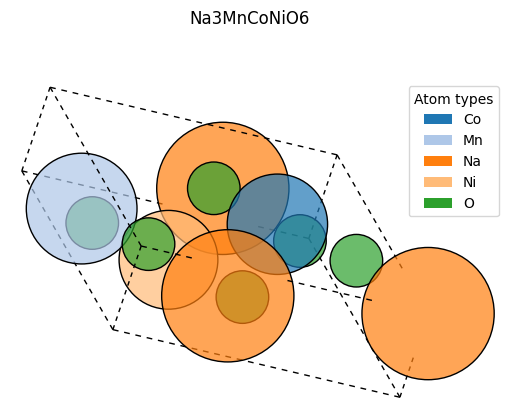

In [13]:
x_cif = df.iloc[0]["cif"]

ax = mp_20_plot(x_cif)

plt.show()

## Datamodule

In [14]:
batch_size = OmegaConf.create(
    {
        "train": 4,
        "val": 4,
        "test": 4,
    }
)

num_workers = OmegaConf.create(
    {
        "train": 0,
        "val": 0,
        "test": 0,
    }
)

datamodule = CrystDataModule(
    train_dataset=MP20_dataset,
    val_dataset=None,
    test_dataset=None,
    batch_size=batch_size,
    num_workers=num_workers,
)

train_loader = datamodule.train_dataloader()

In [15]:
# Inspect one batch
batch = next(iter(train_loader))
print(batch)

ChemGraphBatch(pos=[36, 3], num_atoms=[4], num_nodes=36, energy_above_hull=[4], formation_energy_per_atom=[4], space_group=[4], dft_band_gap=[4], atomic_numbers=[36], cell=[4, 3, 3], batch=[36], ptr=[5])


In [16]:
print("num graphs:", batch.num_graphs)
print("num nodes:", batch.num_nodes)
print("atomic_numbers shape:", batch.atomic_numbers.shape)
print("pos shape:", batch.pos.shape)
print("cell shape:", batch.cell.shape)

num graphs: 4
num nodes: tensor(36)
atomic_numbers shape: torch.Size([36])
pos shape: torch.Size([36, 3])
cell shape: torch.Size([4, 3, 3])


In [17]:
for i in batch:
    print(i)

('pos', tensor([[0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000],
        [0.0000, 0.4038, 0.6817],
        [0.5000, 0.1327, 0.2390],
        [0.0000, 0.5962, 0.3183],
        [0.5000, 0.8673, 0.7610],
        [0.3408, 0.3408, 0.3408],
        [0.6592, 0.6592, 0.6592],
        [0.0000, 0.0000, 0.5000],
        [0.0000, 0.5000, 0.0000],
        [0.5000, 0.0000, 0.0000],
        [0.7075, 0.2925, 0.0000],
        [0.2925, 0.0000, 0.7075],
        [0.0000, 0.7075, 0.2925],
        [0.7075, 0.0000, 0.2925],
        [0.0000, 0.2925, 0.7075],
        [0.2925, 0.7075, 0.0000],
        [0.6565, 0.6565, 0.1544],
        [0.6565, 0.1544, 0.6565],
        [0.1544, 0.6565, 0.6565],
        [0.3435, 0.3435, 0.8456],
        [0.3435, 0.8456, 0.3435],
        [0.8456, 0.3435, 0.3435],
        [0.0964, 0.0964, 0.0964],
        [0.9036, 0.9036, 0.9036],
        [0.0000, 0.0000, 0.0000],
        [0.5000, 0.3333, 0.6667],
        [0.5000, 0.6667, 0.3333],
        [0.5000, 0.0047, 0.1955],
      

## Dataset Statistics

- Make a distribution over atoms. Compare it to general crystallography distribution or distribution found in nature.
- 

## Dataset Lookup

The corresponding `DataFrame` for the dataset can be loaded. This enables lookup of materials/structures using `structures_id` and `materials_id`. One can then trace back to get e.g. the `cif` file for an already-processed data point.

In [34]:
# Get structures ID for some data point
struc_id = str(MP20_dataset.data.structure_id[9312])
print(struc_id)
print(MP20_dataset.data[9312])

# Get the corresponding CIF file
cif_file = MP20_dataset.df[MP20_dataset.df["material_id"] == struc_id]["cif"].values[0]

print(cif_file)

mp-18967
ChemGraph(pos=[10, 3], num_atoms=10, num_nodes=10, energy_above_hull=0.0, formation_energy_per_atom=-2.465796947479248, space_group=225, dft_band_gap=0.0, atomic_numbers=[10], cell=[1, 3, 3])
# generated using pymatgen
data_Ba2CoMoO6
_symmetry_space_group_name_H-M   'P 1'
_cell_length_a   5.80204972
_cell_length_b   5.80511546
_cell_length_c   10.05797779
_cell_angle_alpha   73.23331919
_cell_angle_beta   90.02110813
_cell_angle_gamma   119.96271517
_symmetry_Int_Tables_number   1
_chemical_formula_structural   Ba2CoMoO6
_chemical_formula_sum   'Ba4 Co2 Mo2 O12'
_cell_volume   276.76606788
_cell_formula_units_Z   2
loop_
 _symmetry_equiv_pos_site_id
 _symmetry_equiv_pos_as_xyz
  1  'x, y, z'
loop_
 _atom_site_type_symbol
 _atom_site_label
 _atom_site_symmetry_multiplicity
 _atom_site_fract_x
 _atom_site_fract_y
 _atom_site_fract_z
 _atom_site_occupancy
  Ba  Ba0  1  0.62483500  0.24951500  0.12466700  1
  Ba  Ba1  1  0.12496500  0.25000400  0.62504400  1
  Ba  Ba2  1  0.875035

## Dataset Transforms

Dataset transforms "only" remove/add data points on a meta level. It doesn't transform dataset properties themselves. Below is the MP20 dataset illustrated with `filter_elements` and `filter_energy_above_hull`. We just recreate what MatterGen has done:
- Exclude structures containing the elements `Tc`, `Pm`, or any element with atomic number 84 or higher.
- For the training set, remove any structure with energy above the hull higher than 0.1 eV/atom.

In [18]:
# Exclude Tc, Pm, all elements with Z>=84
excluded_elements = [43, 61] + list(range(84, 118 + 1))  # noqa: RUF005

dataset_transforms = [
    partial(filter_elements, exclude_elements=excluded_elements),  # exclude certain elements
    partial(filter_energy_above_hull, threshold=0.1),  # filter structures with energy above hull > 0.1 eV/atom
]

MP20_filtered = MP20(root="data", split="train", download=False, dataset_transforms=dataset_transforms)

print(len(MP20_filtered))
print(len(MP20_filtered.df))

25344
25344


Check that DataFrame and dataset are in sync:

In [19]:
MP20_filtered.df.iloc[9312]

Unnamed: 0.1                                                              9967
Unnamed: 0                                                               31427
material_id                                                          mp-754314
formation_energy_per_atom                                            -2.180228
dft_band_gap                                                               0.0
pretty_formula                                                      Li4Cr3NiO8
energy_above_hull                                                     0.022461
elements                                               ['Cr', 'Li', 'Ni', 'O']
cif                          # generated using pymatgen\ndata_Li4Cr3NiO8\n_...
space_group                                                               R-3m
spacegroup.number.conv                                                     166
cif.conv                     # generated using pymatgen\ndata_Li4Cr3NiO8\n_...
Name: 9312, dtype: object

In [20]:
MP20_filtered[9312]

ChemGraph(pos=[16, 3], num_atoms=16, num_nodes=16, energy_above_hull=0.022461475804448128, formation_energy_per_atom=-2.180227756500244, space_group=166, dft_band_gap=0.0, atomic_numbers=[16], cell=[1, 3, 3])

In [21]:
str(MP20_filtered.data.structure_id[9312]) == MP20_filtered.df.iloc[9312]["material_id"]

True

## Graph Transforms

Fully connected graph, continuous interval lattice and feature concatenation all in one transform:

In [2]:
transforms = [
    FullyConnectedGraph(),  # fully connected graph representation of the crystal structure
    ContinuousIntervalLattice(),  # continuous interval representation of lattice parameters
    ConcatFeatures(in_keys=["lengths", "angles"], out_key="l"),  # concatenation of lengths and angles into a single feature vector "l"
]

MP20_dataset_test = MP20(root="data", split="train", download=False, transforms=transforms)

Fully connected adjacency matrix:

In [3]:
MP20_dataset_test[0]["edge_node_index"]

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
          1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,
          3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
          4,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
          6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,
          8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,
          9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11,
         11, 11, 11, 11, 11, 11],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  2,  3,  4,  5,  6,  7,
          8,  9, 10, 11,  0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,
          4,  5,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  5,  6,  7,  8,  9, 10,
         11,  0,  1,  2,  3,  4,  6,  7,  8,  9, 10, 11,  0,  1,  2,  3,  4,  5,
          7,  8,  9, 10, 11,  0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11,  0

Lengths $a$, $b$ and $c$:

In [4]:
MP20_dataset_test[0]["lengths"]

tensor([1.1083, 1.7294, 2.0766])

Angles $\alpha$, $\beta$ and $\gamma$:

In [5]:
MP20_dataset_test[0]["angles"]

tensor([0.3155, 0.1934, 0.0000])

Concatenated lengths and angles in $\log$-scaled lattice structure:

In [6]:
MP20_dataset_test[0]["l"]

tensor([1.1083, 1.7294, 2.0766, 0.3155, 0.1934, 0.0000])